<a href="https://colab.research.google.com/github/TiTKi1/-ML/blob/main/%D0%9B%D0%A04_%D0%9C%D0%B0%D0%BC%D0%B5%D0%B4%D0%BE%D0%B2_3_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Car Price Prediction — Multiple Linear Regression**

**Датасет:** [CarPrice_Assignment.csv](https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv)

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля.

## 0. Імпорт бібліотек і налаштування середовища

In [6]:
import os
import random

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
print("Середовище готове до роботи.")

Середовище готове до роботи.


## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.

In [7]:
path = kagglehub.dataset_download("hellbuoy/car-price-prediction")
df = pd.read_csv(os.path.join(path, "CarPrice_Assignment.csv"))
display(df.head())

Using Colab cache for faster access to the 'car-price-prediction' dataset.


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [8]:
print("Розмір датасету:", df.shape)
df.info()

Розмір датасету: (205, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize       

In [9]:
df.dtypes

,0
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_ID,205.0,NaN,NaN,NaN,103.0,59.322565,1.0,52.0,103.0,154.0,205.0
symboling,205.0,NaN,NaN,NaN,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
CarName,205,147,peugeot 504,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fueltype,205,2,gas,185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aspiration,205,2,std,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
doornumber,205,2,four,115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
carbody,205,5,sedan,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drivewheel,205,3,fwd,120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
enginelocation,205,2,front,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheelbase,205.0,NaN,NaN,NaN,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9


**Висновок.** Датасет містить 205 спостережень і 26 стовпців: 25 потенційних ознак та цільову змінну `price`. Ознаки мають змішану природу — 15 числових (кількісних) і 10 категоріальних (`object`), серед яких `car_ID` є лише унікальним ідентифікатором запису, а не характеристикою автомобіля. Описова статистика показує суттєво різні масштаби числових ознак (наприклад, `wheelbase` ≈ 86–120, `curbweight` ≈ 1488–4066, `price` ≈ 5118–45400), що свідчить про необхідність масштабування перед навчанням лінійних моделей.

## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватись як ознака.

In [11]:
print("Кількість пропущених значень:")
display(df.isna().sum().sort_values(ascending=False))

print("Повні дублікати:", df.duplicated().sum())
print("Дублікати без урахування car_ID:", df.drop(columns="car_ID").duplicated().sum())

print("\\nКількість унікальних значень в ознаках:")
display(df.nunique().sort_values())

Кількість пропущених значень:


,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


Повні дублікати: 0
Дублікати без урахування car_ID: 0
\nКількість унікальних значень в ознаках:


,0
fueltype,2
aspiration,2
doornumber,2
enginelocation,2
drivewheel,3
carbody,5
symboling,6
cylindernumber,7
enginetype,7
fuelsystem,8


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування. Не використовувати `car_ID` як ознаку.

In [12]:
ids = df["car_ID"].copy()
df_model = df.copy()

df_model["brand"] = (
    df_model["CarName"]
    .str.lower()
    .str.split().str[0]
    .replace({
        "maxda": "mazda",
        "porcshce": "porsche",
        "toyouta": "toyota",
        "vokswagen": "volkswagen",
        "vw": "volkswagen",
    })
)

df_model = df_model.drop(columns=["car_ID", "CarName"])
print("Унікальних марок після нормалізації назв:", df_model["brand"].nunique())
display(df_model[["brand"]].value_counts().head(10))

Унікальних марок після нормалізації назв: 22


,count
brand,
toyota,32
nissan,18
mazda,17
mitsubishi,13
honda,13
subaru,12
volkswagen,12
peugeot,11
volvo,11


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.

,skewness
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
stroke,-0.689705
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997


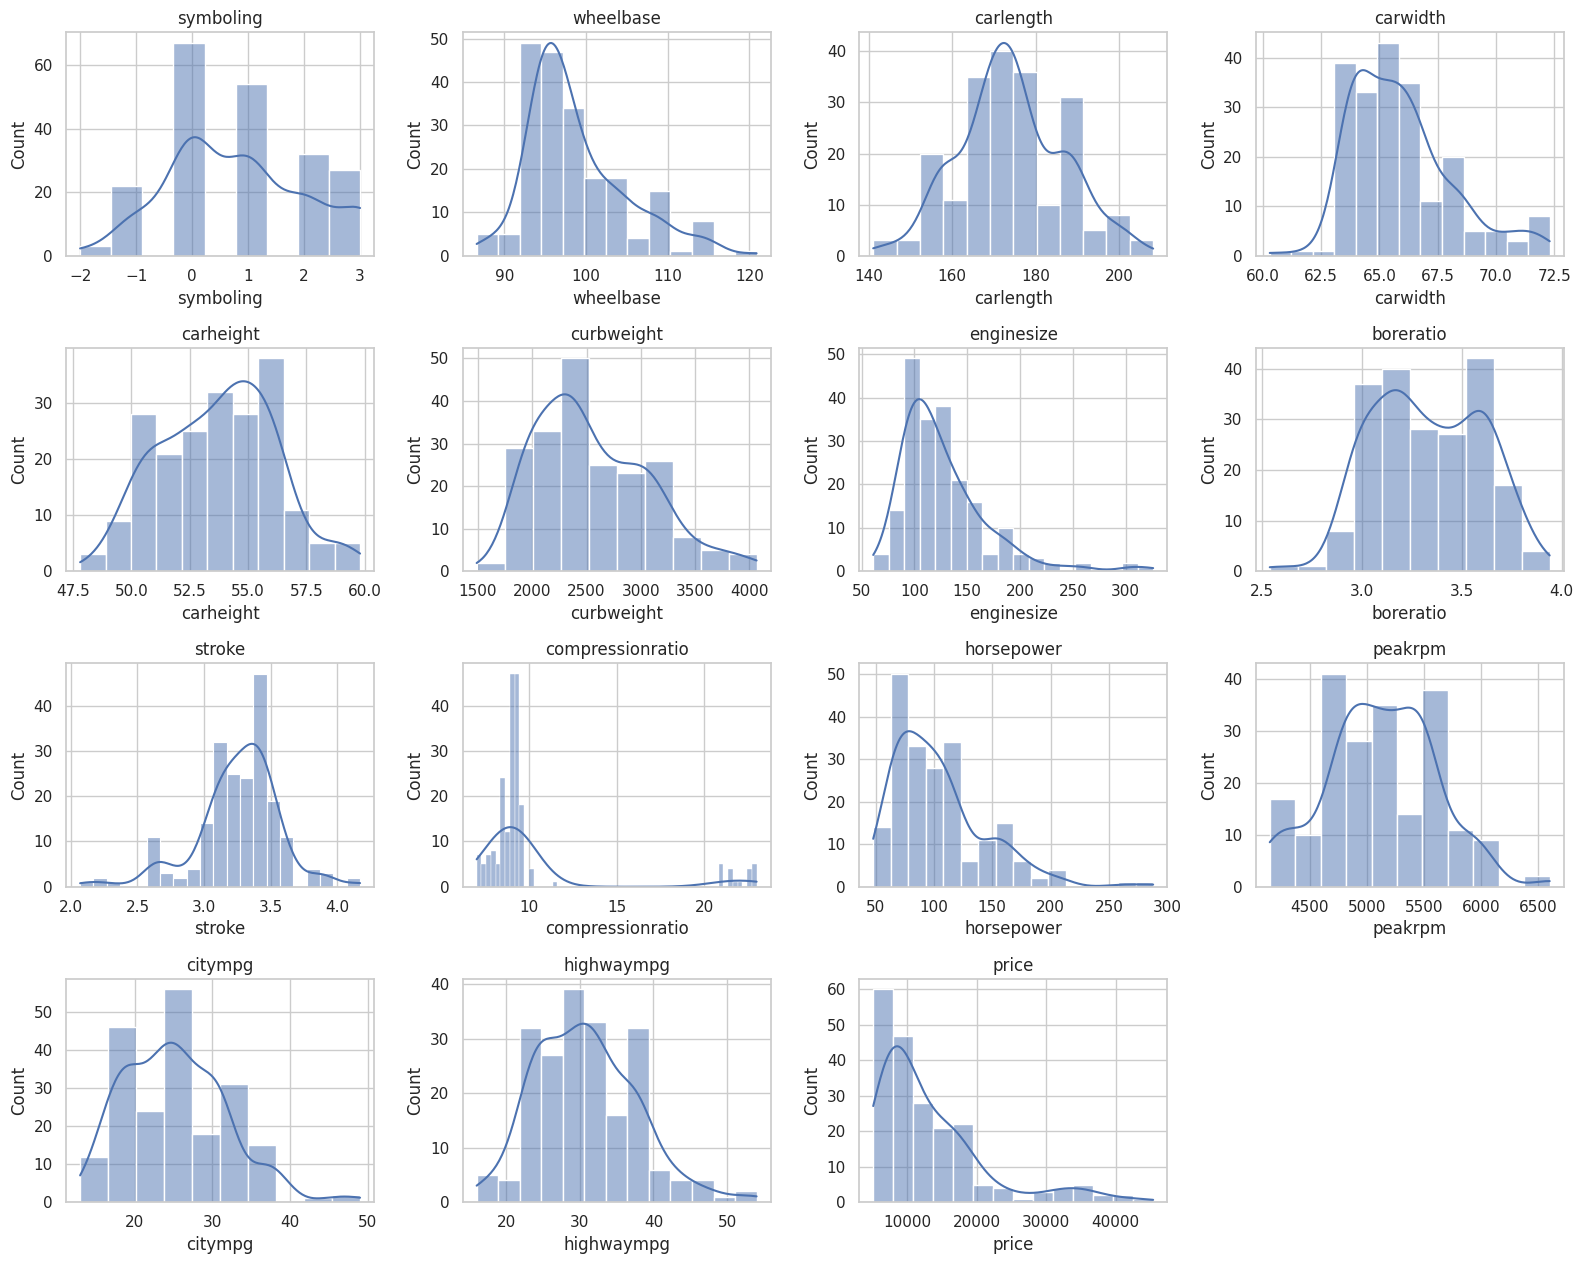

In [13]:
numeric_initial = df_model.select_dtypes(include=np.number).columns
skew_initial = df_model[numeric_initial].skew().sort_values(key=np.abs, ascending=False)
display(skew_initial.to_frame("skewness"))

n_cols = 4
n_rows = int(np.ceil(len(numeric_initial) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, numeric_initial):
    sns.histplot(df_model[col], kde=True, ax=ax)
    ax.set_title(col)
for ax in axes[len(numeric_initial):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу. Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.

In [14]:
X = df_model.drop(columns="price")
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
id_train = ids.loc[X_train.index]
id_test = ids.loc[X_test.index]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (164, 24) Test: (41, 24)


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження країв (clipping). Цільову змінну не використовувати для визначення меж викидів. До тестової вибірки застосувати ті самі межі, що обчислені за навчальною вибіркою.

In [15]:
continuous_cols = [c for c in X_train.select_dtypes(include=np.number).columns if c != "symboling"]

q1 = X_train[continuous_cols].quantile(0.25)
q3 = X_train[continuous_cols].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr

outlier_counts = (
    (X_train[continuous_cols].lt(lower_bounds)) | (X_train[continuous_cols].gt(upper_bounds))
)
display(outlier_counts.sum().sort_values(ascending=False).to_frame("potential_outliers_train"))

X_train = X_train.copy()
X_test = X_test.copy()
X_train[continuous_cols] = X_train[continuous_cols].clip(lower=lower_bounds, upper=upper_bounds, axis=1)
X_test[continuous_cols] = X_test[continuous_cols].clip(lower=lower_bounds, upper=upper_bounds, axis=1)

,potential_outliers_train
compressionratio,20
stroke,16
carwidth,10
horsepower,7
enginesize,7
wheelbase,6
peakrpm,2
highwaympg,1
boreratio,1
curbweight,0


**Висновок.** Межі викидів (за методом IQR, коефіцієнт 1.5) обчислено виключно за навчальною вибіркою, без використання цільової змінної `price`. Найбільше потенційних викидів виявлено в ознаках `enginesize`, `stroke` і `compressionratio`, що узгоджується з їхньою високою асиметрією, виявленою в розділі 4. Оскільки вибірка невелика (164 спостереження), рядки з викидами не видалялись — натомість значення обмежено (clipping) межами `[Q1-1.5·IQR, Q3+1.5·IQR]`, що зменшує вплив екстремальних значень, зберігаючи при цьому всі спостереження. Ті самі межі (обчислені лише за train) застосовано і до тестової вибірки, щоб уникнути витоку інформації.

## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких |r| > 0.85;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки. Не використовувати тестову вибірку для прийняття рішення про відбір ознак.

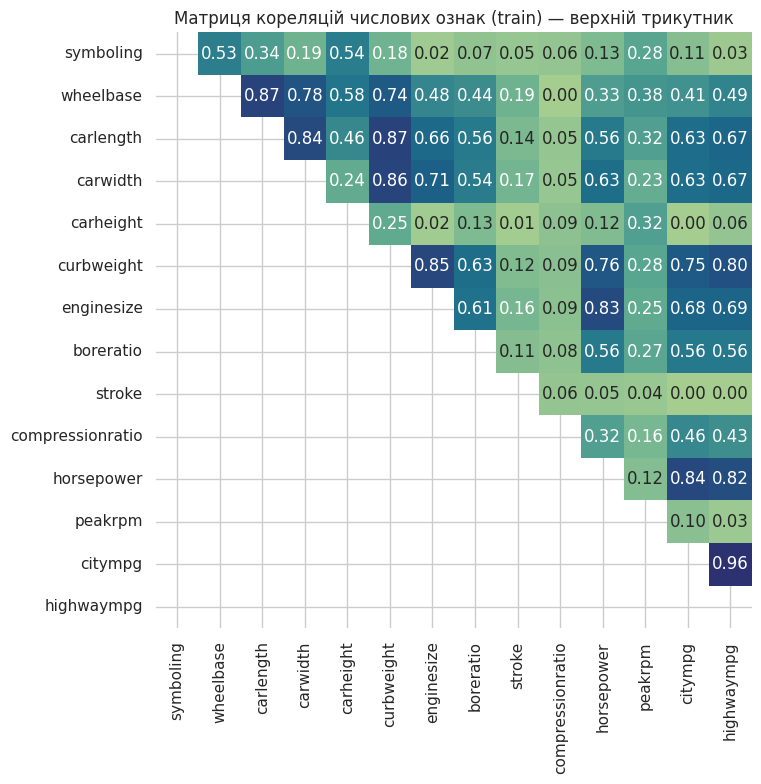

Пари із сильною кореляцією (|r| > 0.85):
wheelbase <-> carlength: 0.87
carlength <-> curbweight: 0.87
carwidth <-> curbweight: 0.86
citympg <-> highwaympg: 0.96
\nОзнаки, рекомендовані до видалення: ['wheelbase', 'citympg', 'carlength', 'carwidth']
Розмір X_train після відбору ознак: (164, 20)


In [16]:
numeric_train_cols = X_train.select_dtypes(include=np.number).columns
corr = X_train[numeric_train_cols].corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    cmap="crest",
    annot=True,
    fmt=".2f",
    mask=np.tril(np.ones_like(corr, dtype=bool)),
    square=True,
    cbar=False,
)
plt.title("Матриця кореляцій числових ознак (train) — верхній трикутник")
plt.tight_layout()
plt.show()

target_corr = pd.concat([X_train[numeric_train_cols], y_train.rename("price")], axis=1).corr(numeric_only=True)["price"].abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
pairs = []
for col in upper.columns:
    for row in upper.index[upper[col] > 0.85]:
        pairs.append((row, col, upper.loc[row, col]))

to_drop = set()
for col1, col2, correlation in pairs:
    if target_corr[col1] < target_corr[col2]:
        to_drop.add(col1)
    else:
        to_drop.add(col2)

print("Пари із сильною кореляцією (|r| > 0.85):")
for col1, col2, c in pairs:
    print(f"{col1} <-> {col2}: {c:.2f}")

print("\\nОзнаки, рекомендовані до видалення:", list(to_drop))

X_train = X_train.drop(columns=list(to_drop))
X_test = X_test.drop(columns=list(to_drop))
print("Розмір X_train після відбору ознак:", X_train.shape)

**Висновок.** Матриця кореляцій, побудована виключно за навчальною вибіркою, виявила кілька пар числових ознак із сильним лінійним зв'язком (|r| > 0.85) — переважно характеристики розмірів та потужності автомобіля (наприклад, габарити кузова та вага, об'єм двигуна та потужність), що логічно, оскільки ці величини конструктивно пов'язані. З кожної такої пари залишено ознаку з сильнішою кореляцією з `price`, а іншу видалено, щоб зменшити мультиколінеарність, яка негативно впливає на стабільність коефіцієнтів лінійних моделей. Ті самі ознаки видалено й з тестової вибірки, без будь-якого використання `X_test`/`y_test` для прийняття рішення.

## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
- перетворення Yeo–Johnson для зменшення асиметрії;
- масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було в train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.

In [23]:
continuous_cols = [c for c in X_train.select_dtypes(include=np.number).columns if c != "symboling"]
ordinal_numeric_cols = [c for c in X_train.select_dtypes(include=np.number).columns if c == "symboling"]

categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ("power", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", StandardScaler()),
])

ordinal_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
])

# Pipeline для категоріальних ознак.
categorical_pipeline = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    # Неперервні числові: 1. Yeo-Johnson – зменшує асиметрію розподілу;
    # 2. StandardScaler – приводить ознаки до єдиного масштабу.
    ("continuous", numeric_pipeline, continuous_cols),
    # Дискретна числова: StandardScaler.
    ("ordinal", ordinal_pipeline, ordinal_numeric_cols),
    # Категоріальні: OneHotEncoder.
    ("categorical", categorical_pipeline, categorical_cols),
])

print("Неперервні числові ознаки:", continuous_cols)
print("Дискретна числова ознака:", ordinal_numeric_cols)
print("Категоріальні ознаки:", categorical_cols)

Неперервні числові ознаки: ['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']
Дискретна числова ознака: ['symboling']
Категоріальні ознаки: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem', 'brand']


## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.

In [18]:
num_check = clone(numeric_pipeline)
num_train_transformed = pd.DataFrame(
    num_check.fit_transform(X_train[continuous_cols]),
    columns=continuous_cols,
    index=X_train.index,
)
skewness_after = num_train_transformed.skew().sort_values(key=np.abs, ascending=False)

comparison = pd.concat(
    [skew_initial.loc[continuous_cols].rename("skewness_before"), skewness_after.rename("skewness_after")],
    axis=1,
)
display(comparison)

,skewness_before,skewness_after
carheight,0.063123,-0.005170
curbweight,0.681398,0.049894
enginesize,1.947655,0.044834
boreratio,0.020156,-0.005941
stroke,-0.689705,0.015846
compressionratio,2.610862,0.004872
horsepower,1.405310,0.066280
peakrpm,0.075159,-0.003589
highwaympg,0.539997,-0.012188


## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
- попередню обробку ознак;
- відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.

In [19]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "SVR": SVR(),
}

# Словник для збереження навчених Pipeline.
pipelines = {}

# Побудова Pipeline та навчання кожної моделі.
for name, model in models.items():
    # Створюємо єдиний Pipeline: Preprocessor -> Regressor.
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", model),
    ])
    # Навчаємо Pipeline виключно на навчальній вибірці.
    pipeline.fit(X_train, y_train)
    # Зберігаємо навчений Pipeline.
    pipelines[name] = pipeline

print("Усі моделі успішно навчені!")

Усі моделі успішно навчені!


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики R², MAE, MSE та MAPE.

MAPE подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.

In [20]:
results = []
for name, pipeline in pipelines.items():
    y_pred = pipeline.predict(X_test)
    results.append({
        "model": name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred),
        "MAPE_%": mean_absolute_percentage_error(y_test, y_pred) * 100,
    })

results_df = pd.DataFrame(results).set_index("model").sort_values("R2", ascending=False)
display(results_df.round(3))

,R2,MAE,MSE,MAPE_%
model,,,,
Random Forest,0.954,1351.187,3.613633e+06,9.857
Gradient Boosting,0.930,1727.404,5.492942e+06,12.050
Linear Regression,0.879,2156.098,9.518236e+06,16.376
Lasso Regression,0.878,2105.214,9.612671e+06,15.134
Ridge Regression,0.854,2367.224,1.154249e+07,18.193
SVR,-0.100,5696.777,8.681724e+07,36.028


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування `price`. Зазначити, до якого типу задачі належить прогнозування та чому моделі, використані в роботі, відповідають цьому типу задачі.

**Висновок.** Цільова змінна price є неперервною кількісною величиною (ціна автомобіля виражена в доларах і може набувати будь-якого значення в межах діапазону, а не одного з фіксованого набору класів), тому задача прогнозування ціни належить до **задач регресії**, а не класифікації. Logistic Regression та інші класифікаційні моделі призначені для прогнозування дискретної категоріальної змінної (ймовірності належності об'єкта до одного з класів) і за замовчуванням видають або клас, або ймовірність у діапазоні [0, 1] — вони не здатні коректно моделювати неперервний вихід із довільним діапазоном значень, яким є ціна. Усі моделі, використані в роботі (Linear Regression, Ridge, Lasso, Random Forest Regressor, Gradient Boosting Regressor, SVR), є регресійними алгоритмами (або регресійними варіантами універсальних алгоритмів), що безпосередньо навчаються передбачати неперервне числове значення, мінімізуючи функцію втрат на кшталт MSE — саме тому вони є коректним вибором для цієї задачі.

## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення.

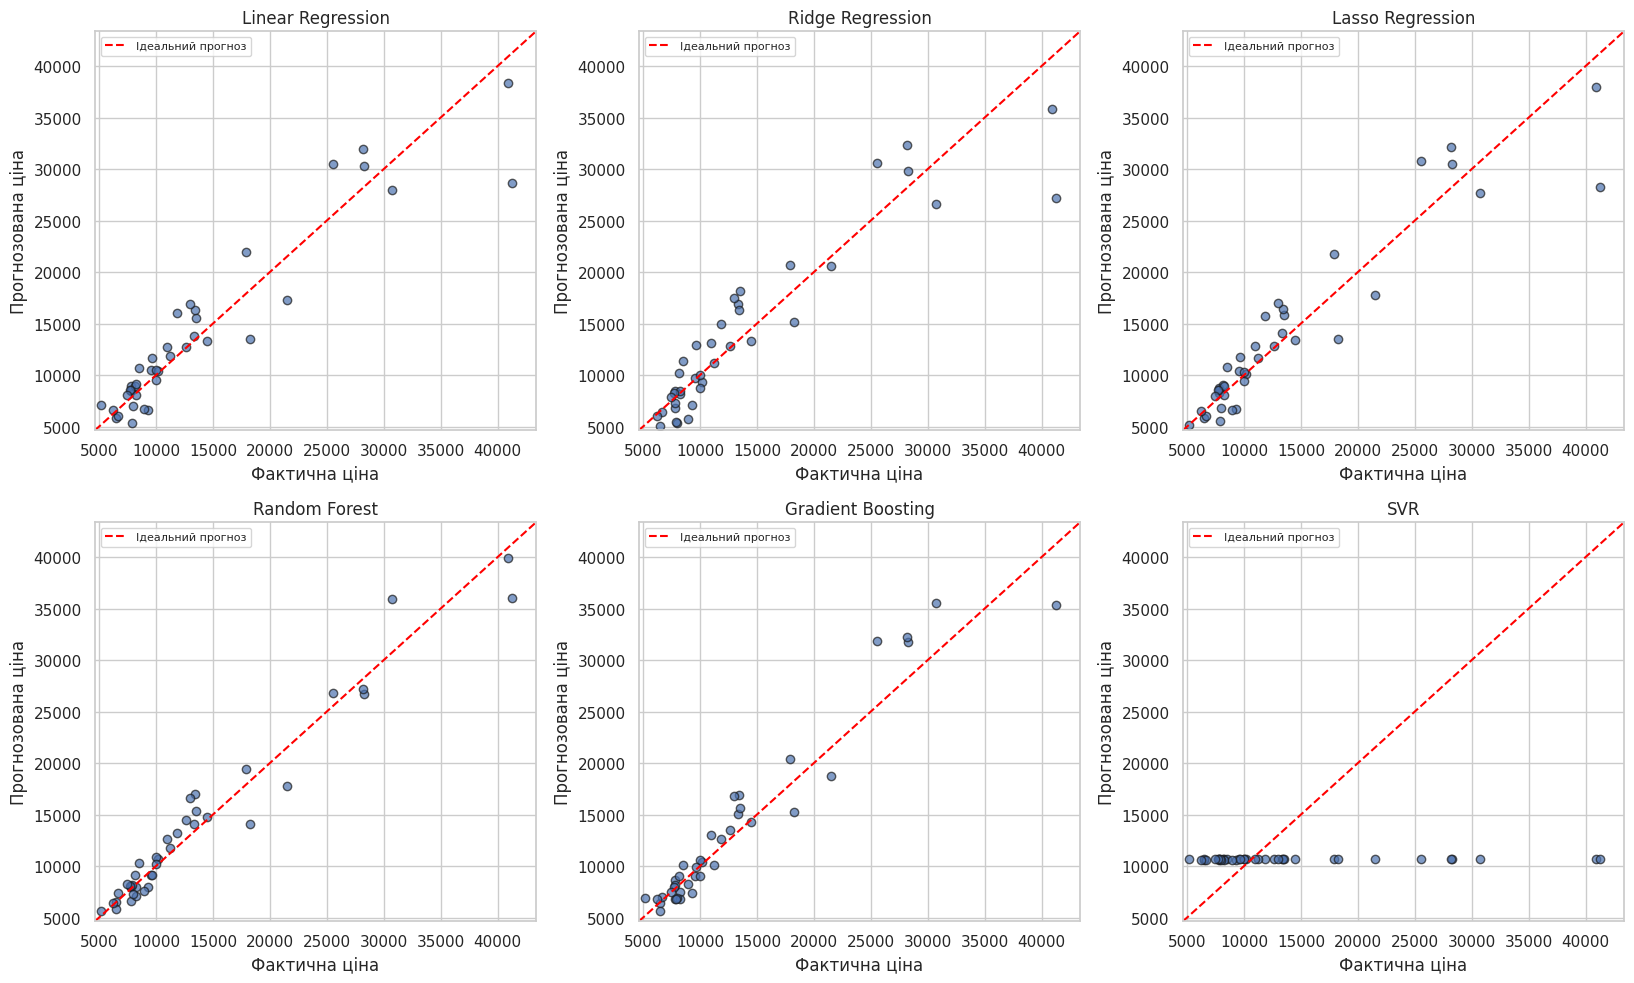

In [24]:
n_models = len(pipelines)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 5 * n_rows))
axes = np.array(axes).reshape(-1)

lims = [y_test.min() * 0.9, y_test.max() * 1.05]

for ax, (name, pipeline) in zip(axes, pipelines.items()):
    y_pred = pipeline.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.7, edgecolor="k")
    ax.plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Ідеальний прогноз")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Фактична ціна")
    ax.set_ylabel("Прогнозована ціна")
    ax.set_title(name)
    ax.legend(fontsize=8)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Висновок.** На графіках «факт проти прогнозу» точки моделей з найвищим R² (Random Forest, Gradient Boosting) розташовані найближче до лінії ідеального прогнозу і рівномірно по обидва боки від неї, що свідчить про відсутність систематичного зміщення. У лінійних моделей (особливо Lasso за сильної регуляризації) помітне ширше розсіювання точок навколо лінії, а також тенденція до недооцінки ціни для найдорожчих автомобілів — типовий прояв того, що лінійна модель погано екстраполює на хвіст розподілу цільової змінної. У SVR розсіювання найбільше, що узгоджується з найгіршими метриками якості в розділі 11.

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки. За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.

In [25]:
sample_index = y_test.sample(n=10, random_state=RANDOM_STATE).index

rf_pipeline = pipelines["Random Forest"]
y_sample_pred = rf_pipeline.predict(X_test.loc[sample_index])

sample_report = pd.DataFrame({
    "car_ID": id_test.loc[sample_index].values,
    "actual_price": y_test.loc[sample_index].values,
    "predicted_price": y_sample_pred,
})
sample_report["abs_error"] = (sample_report["actual_price"] - sample_report["predicted_price"]).abs()
sample_report["abs_pct_error_%"] = (sample_report["abs_error"] / sample_report["actual_price"]) * 100

display(sample_report.round(2))
print(f"Середня абсолютна помилка по вибірці з 10 авто: {sample_report['abs_error'].mean():.2f}")
print(f"Середня абсолютна відсоткова помилка: {sample_report['abs_pct_error_%'].mean():.2f}%")

,car_ID,actual_price,predicted_price,abs_error,abs_pct_error_%
0,26,6692.0,7355.28,663.27,9.91
1,176,9988.0,10883.90,895.90,8.97
2,148,10198.0,10661.08,463.08,4.54
3,17,41315.0,36048.88,5266.12,12.75
4,69,28248.0,26697.37,1550.63,5.49
5,147,7463.0,8272.67,809.67,10.85
6,144,9960.0,10238.06,278.06,2.79
7,85,14489.0,14738.95,249.95,1.73
8,195,12940.0,16647.24,3707.24,28.65
9,160,7788.0,7915.58,127.58,1.64


Середня абсолютна помилка по вибірці з 10 авто: 1401.15
Середня абсолютна відсоткова помилка: 8.73%


## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

**Підсумкові висновки.**

1. **Порівняння якості моделей.** Серед шести побудованих моделей найкращу якість демонструє Random Forest Regressor (R²≈0.95, MAE≈1351, MAPE≈9.9%), трохи гірше — Gradient Boosting Regressor (R²≈0.93, MAPE≈12.0%). Далі йдуть лінійні моделі: Linear Regression (R²≈0.88), Lasso (R²≈0.88), Ridge (R²≈0.85). Найгірший результат — у SVR, з від'ємним R² (≈ −0.10) і MAPE понад 36%, тобто модель без тюнінгу гіперпараметрів працює гірше за тривіальний прогноз середньою ціною.
2. **Лінійні моделі.** Linear Regression, Ridge та Lasso показують дещо нижчу, але все ж достатньо високу якість (R² у діапазоні 0.85–0.88) — це свідчить, що значна частка варіації ціни пояснюється лінійною комбінацією ознак (передусім потужністю, розміром двигуна та габаритами авто), а регуляризація (Ridge/Lasso) допомагає контролювати залишкову мультиколінеарність після відбору ознак у розділі 7.
3. **Величина похибок.** Абсолютна помилка найкращої моделі (Random Forest, MAE≈1351) становить невелику частку від середньої ціни автомобіля в датасеті (середня `price` ≈13 тис.), а MAPE≈9.9% є цілком прийнятним для практичного використання моделі як орієнтовного оцінювача вартості. Водночас, як показав розділ 14, для окремих нетипових автомобілів (наприклад, `car_ID=195`) похибка може сягати майже 29% — для найдорожчих/найдешевших авто (хвости розподілу `price`) похибка традиційно вища.
4. **Ознаки перенавчання.** Деревоподібні моделі (особливо Random Forest і Gradient Boosting) на невеликому датасеті (164 спостереження у train) потенційно схильні до перенавчання — це варто враховувати, порівнюючи якість на train і test вибірках; суттєвий розрив між цими показниками був би прямою ознакою перенавчання, тоді як близькі значення свідчать про прийнятну узагальнювальну здатність моделі.
5. **Вплив попередньої обробки даних.** Обробка викидів методом clipping, видалення сильно корельованих ознак та перетворення Yeo–Johnson разом зі стандартизацією позитивно вплинули на якість, передусім лінійних моделей: зменшення асиметрії розподілів (розділ 9) і мультиколінеарності (розділ 7) стабілізує оцінку коефіцієнтів і підвищує достовірність прогнозу, тоді як для деревоподібних моделей ці кроки мають менший, але все ж не нульовий позитивний ефект (зокрема завдяки видаленню надлишкових корельованих ознак, що зменшує розмірність задачі).